In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols
from scipy.integrate import solve_ivp
import matplotlib.animation as animation

In [82]:
t, L, theta, M, m, g = sp.symbols('t L theta M m g')
thd,  xd   = dynamicsymbols('theta x', 1)    # theta_dot, x_dot

display(L, theta, M, m, g)

mm = sp.Matrix([[M+m, m*L*sp.cos(theta)], [sp.cos(theta), L]])
display(mm)

cc = sp.Matrix([[m*L*sp.sin(theta)*thd**2], [-g*sp.sin(theta)]])
display(cc)

dd = mm.inv() * cc
dd  = sp.simplify(dd)

xdd_sym, thdd_sym = dd[0], dd[1]
display(xdd_sym, thdd_sym)

L

theta

M

m

g

Matrix([
[     M + m, L*m*cos(theta)],
[cos(theta),              L]])

Matrix([
[L*m*sin(theta)*Derivative(theta(t), t)**2],
[                            -g*sin(theta)]])

m*(L*Derivative(theta(t), t)**2 + g*cos(theta))*sin(theta)/(M + m*sin(theta)**2)

-(L*m*cos(theta)*Derivative(theta(t), t)**2 + M*g + g*m)*sin(theta)/(L*(M + m*sin(theta)**2))

In [2]:
m = 1.0
M = 5.0
g = 9.8
L = 2.0

integral_error = 0
Kp, Ki, Kd = 200, 0, 20
KpC = 0.5  # Proportional gain for cart velocity

def pid_controller(t, state):
    x, x_dot, theta, theta_dot, integral_error = state
    error = (np.pi - theta + np.pi) % (2 * np.pi) - np.pi  # Wrap error to [-pi, pi]
    derivative_error = -theta_dot
    pos_error = x

    control = Kp * error + Ki * integral_error + Kd * derivative_error + KpC * pos_error
    F_MAX = 50.0                        # newtons
    F = np.clip(control, -F_MAX, F_MAX)
    return F, error


def derivatives_PID(t, state):
    x, x_dot, theta, theta_dot, __ = state
    F, error = pid_controller(t, state)
    s, c = np.sin(theta), np.cos(theta)
    denom = M + m * s**2
    x_ddot = (F + m * s * (L * theta_dot**2 + g * c)) / denom
    theta_ddot = (-(M + m)*g*s - F*c - m*L*s*c*theta_dot**2) / (L * denom)
    return [x_dot, x_ddot, theta_dot, theta_ddot, error]



In [3]:
theta0 = np.radians(130)
theta_dot0 = np.radians(40)
x0 = 0.0
x_dot0 = 0.0
state0 = [x0, x_dot0, theta0, theta_dot0, integral_error]

t_end = 20
fps = 50
t_eval = np.linspace(0, t_end, t_end*fps)
sol = solve_ivp(derivatives_PID, [0, t_end], state0, t_eval=t_eval, rtol=1e-9, atol=1e-9)

x, x_dot, theta, theta_dot, integral_error = sol.y
t = sol.t

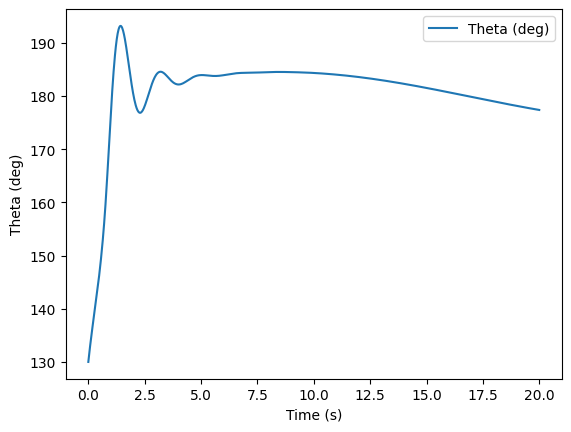

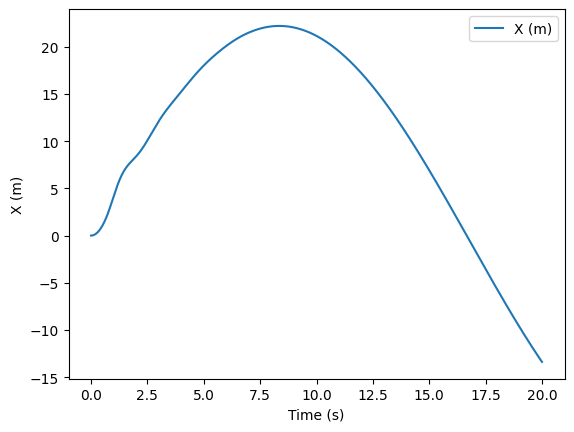

In [4]:
plt.plot(t, np.degrees(theta), label='Theta (deg)')
plt.xlabel('Time (s)')
plt.ylabel('Theta (deg)')
plt.legend()
plt.show()

plt.plot(t, x, label='X (m)')
plt.xlabel('Time (s)')
plt.ylabel('X (m)')
plt.legend()
plt.show()

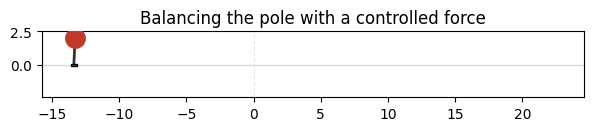

In [ ]:
bob_x = x + L * np.sin(theta)
bob_y = -L * np.cos(theta)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.set_xlim(x.min() - L - 0.4, x.max() + L + 0.4)
ax.set_ylim(-L - 0.4, L + 0.5)
ax.set_aspect('equal')
ax.axhline(0, color='0.85', lw=1)
ax.axvline(0, color='0.9', lw=0.8, ls='--')      # cart target position
ax.set_title("Balancing the pole with a controlled force")
 
cart_w, cart_h = 0.4, 0.2
cart = plt.Rectangle((0, -cart_h/2), cart_w, cart_h, fc='#3b6ea5', ec='k', zorder=3)
ax.add_patch(cart)
rod,   = ax.plot([], [], '-', color='#333', lw=2, zorder=2)
bob,   = ax.plot([], [], 'o', color='#c0392b', ms=14, zorder=4)
 
def animate(i):
    cx = x[i]
    cart.set_xy((cx - cart_w/2, -cart_h/2))
    rod.set_data([cx, bob_x[i]], [0, bob_y[i]])
    bob.set_data([bob_x[i]], [bob_y[i]])
    scale = 0.06
    return cart, rod, bob
 
ani = animation.FuncAnimation(fig, animate, frames=len(t_eval),
                              interval=1000/fps, blit=True)

ani.save("cart_pole_control.gif", writer=animation.FFMpegWriter(fps=fps))